##  Task 1: Problem Understanding

###  Goal:
Classify text into:
- Positive 😊
- Negative 😠

###  Why?
Businesses use sentiment analysis to:
- Understand customer feedback
- Improve products
- Make decisions

We will build a machine learning model using NLP.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
# Load Twitter dataset
twitter_df = pd.read_csv("/content/twitter.csv")

# Load Amazon dataset
amazon_df = pd.read_csv("/content/amazon_reviews.csv")

twitter_df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [5]:
print(twitter_df.info())
print(twitter_df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
None
label
0    29720
1     2242
Name: count, dtype: int64


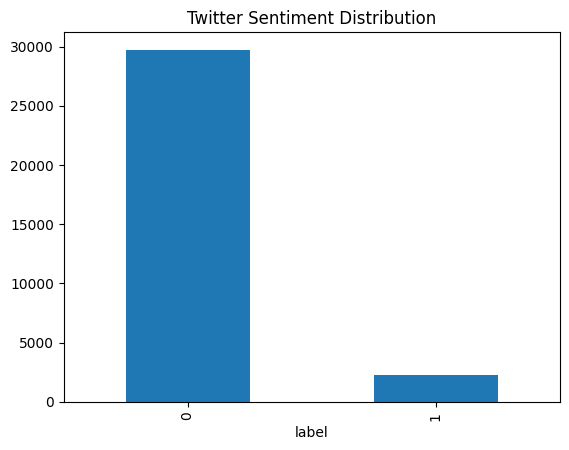

In [6]:
# Visualization
twitter_df['label'].value_counts().plot(kind='bar')
plt.title("Twitter Sentiment Distribution")
plt.show()

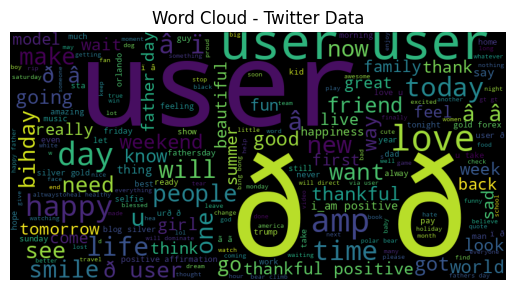

In [7]:
from wordcloud import WordCloud

text = " ".join(twitter_df['tweet'])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud - Twitter Data")
plt.show()

In [8]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

twitter_df['clean'] = twitter_df['tweet'].apply(remove_punctuation)

In [9]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word.lower() not in stop_words])

twitter_df['clean'] = twitter_df['clean'].apply(remove_stopwords)

In [10]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(twitter_df['clean'])
y = twitter_df['label']

In [11]:
def full_preprocess(text):
    text = text.lower()
    text = remove_punctuation(text)
    text = remove_stopwords(text)
    return text

twitter_df['clean'] = twitter_df['tweet'].apply(full_preprocess)

##  Naive Bayes Theory

Formula:
P(Class | Text) = P(Text | Class) × P(Class)

### Assumption:
Words are independent (Naive assumption)

### Why used?
✔ Fast  
✔ Works great for text  
✔ Handles large vocabulary

In [12]:
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9465039887376818
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      5949
           1       0.63      0.55      0.59       444

    accuracy                           0.95      6393
   macro avg       0.80      0.76      0.78      6393
weighted avg       0.94      0.95      0.94      6393



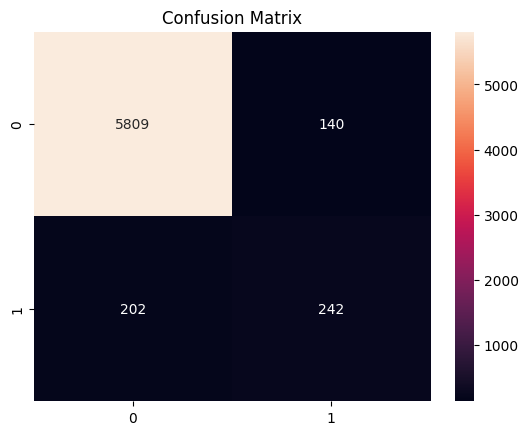

In [14]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [15]:
amazon_df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


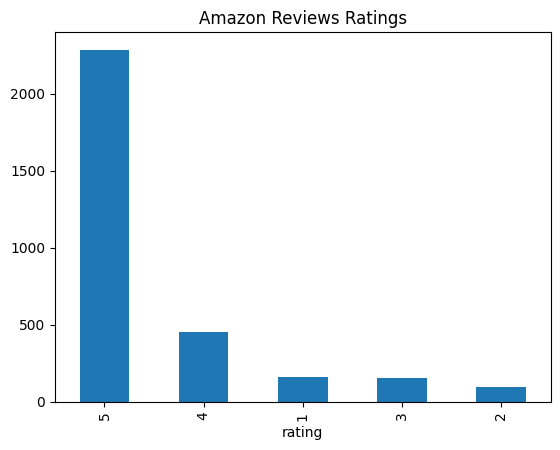

In [17]:
amazon_df['rating'].value_counts().plot(kind='bar')
plt.title("Amazon Reviews Ratings")
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

print("LR Accuracy:", accuracy_score(y_test, lr.predict(X_test)))

LR Accuracy: 0.9594869388393555


In [19]:
def predict_sentiment(text):
    text = full_preprocess(text)
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]

predict_sentiment("I love this product!")

np.int64(0)